In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.2 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you 

In [41]:
!git clone https://github.com/Thanhmay2406/xai-driven-saliency-loss.git

Cloning into 'xai-driven-saliency-loss'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 114 (delta 30), reused 109 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 19.77 MiB | 33.51 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [3]:
from pathlib import Path
from typing import Any
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from ultralytics import YOLO


REPO_ROOT = Path('/kaggle/working/xai-driven-saliency-loss')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.xai.eigencam import EigenCAM
from src.xai.gradcam import GradCAM
from src.xai.gradcampp import GradCAMPlusPlus
from src.xai.saliency_utils import (
    draw_boxes,
    find_yolo_saliency_target_layer,
    get_split_image_dir,
    get_split_label_dir,
    label_path_from_image,
    list_image_files,
    load_ground_truth_boxes,
    load_rgb_image,
    load_yaml,
    make_side_by_side,
    overlay_heatmap,
    predictions_to_dicts,
    preprocess_image,
    resolve_path,
    resize_cam,
    save_cam_array,
    save_metadata,
    select_primary_prediction,
)

plt.rcParams["figure.figsize"] = (18, 6)
plt.rcParams["axes.grid"] = False
print(f"Repo root: {REPO_ROOT}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Repo root: /kaggle/working/xai-driven-saliency-loss


In [49]:
WEIGHTS_PATH = Path('/kaggle/working/xai-driven-saliency-loss/output/train_baseline/outputs/yolo/baseline/weights/last.pt')
DATASET_YAML = Path('/kaggle/input/datasets/thanhmay2406/datasettop/merged_yolo_grouped/dataset.yaml')
METHOD = "eigencam"  # chon: gradcam, gradcampp, eigencam
TARGET_BRANCH = "small"  # chon: small, medium, large
SPLIT = "val"      # chon: train, val, test
IMGSZ = 640
CONF = 0.25
DEVICE = 0
MAX_IMAGES = 8
OUTPUT_DIR = Path('/kaggle/working/') / "saliency_maps" / "baseline"

assert DATASET_YAML.exists(), DATASET_YAML
print(WEIGHTS_PATH)
print(DATASET_YAML)

/kaggle/working/xai-driven-saliency-loss/output/train_baseline/outputs/yolo/baseline/weights/last.pt
/kaggle/input/datasets/thanhmay2406/datasettop/merged_yolo_grouped/dataset.yaml


In [50]:
# Ham nay tao doi tuong CAM tuong ung voi method duoc chon.
def build_cam_generator(method: str, detector: torch.nn.Module, target_layer: torch.nn.Module) -> Any:
    if method == "gradcam":
        return GradCAM(detector, target_layer)
    if method == "gradcampp":
        return GradCAMPlusPlus(detector, target_layer)
    if method == "eigencam":
        return EigenCAM(detector, target_layer)
    raise ValueError(f"Unsupported saliency method: {method}")


# Ham nay sinh mot saliency map cho tung anh va tra ve CAM cung score target.
def generate_saliency_map(
    cam_generator: Any,
    method: str,
    image_tensor: torch.Tensor,
    class_id: int,
    num_classes: int,
) -> tuple[np.ndarray, float | None]:
    if method == "eigencam":
        cam_tensor = cam_generator.generate_normalized(image_tensor=image_tensor)
        return cam_tensor.detach().cpu().numpy(), None

    cam_tensor, target_score = cam_generator.generate_normalized(
        image_tensor=image_tensor,
        class_id=class_id,
        num_classes=num_classes,
    )
    return cam_tensor.detach().cpu().numpy(), target_score


# Ham nay luu tat ca artifact saliency cua mot anh gom overlay, panel, numpy va metadata.
def save_saliency_artifacts(
    image_path: Path,
    output_dir: Path,
    boxed_image: Image.Image,
    overlay_image: Image.Image,
    cam_array: np.ndarray,
    metadata: dict[str, Any],
) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = image_path.stem
    heatmap_only = Image.fromarray((cam_array * 255).astype(np.uint8)).convert("L")
    side_by_side = make_side_by_side(boxed_image, overlay_image)

    boxed_image.save(output_dir / f"{stem}_boxes.png")
    overlay_image.save(output_dir / f"{stem}_overlay.png")
    heatmap_only.save(output_dir / f"{stem}_heatmap.png")
    side_by_side.save(output_dir / f"{stem}_panel.png")
    save_cam_array(cam_array, output_dir / f"{stem}_cam.npy")
    save_metadata(metadata, output_dir / f"{stem}_meta.json")


# Ham nay khoi tao model, dataset va CAM generator de dung xuyen suot trong notebook.
def setup_saliency_pipeline(
    weights_path: Path,
    dataset_yaml_path: Path,
    split: str,
    method: str,
):
    dataset_yaml_path = resolve_path(dataset_yaml_path, base_dir=dataset_yaml_path.parent, repo_root=REPO_ROOT)
    dataset_config = load_yaml(dataset_yaml_path)
    image_dir = get_split_image_dir(dataset_config, dataset_yaml_path, split=split, repo_root=REPO_ROOT)
    label_dir = get_split_label_dir(image_dir)

    weights_path = resolve_path(weights_path, base_dir=weights_path.parent, repo_root=REPO_ROOT)
    model = YOLO(str(weights_path))
    detector = model.model
    detector.eval()
    target_layer = find_yolo_saliency_target_layer(detector, prefer_branch=TARGET_BRANCH)
    cam_generator = build_cam_generator(method, detector=detector, target_layer=target_layer)
    names = {int(key): value for key, value in model.names.items()}

    return {
        "model": model,
        "detector": detector,
        "target_layer": target_layer,
        "cam_generator": cam_generator,
        "dataset_config": dataset_config,
        "dataset_yaml_path": dataset_yaml_path,
        "image_dir": image_dir,
        "label_dir": label_dir,
        "names": names,
    }


# Ham nay chay saliency cho mot anh, tao day du metadata va cac anh hien thi.
def run_saliency_for_image(
    pipeline: dict[str, Any],
    image_path: Path,
    method: str,
    imgsz: int,
    conf: float,
    device: str,
) -> dict[str, Any] | None:
    model = pipeline["model"]
    cam_generator = pipeline["cam_generator"]
    names = pipeline["names"]
    label_dir = pipeline["label_dir"]

    original_image = load_rgb_image(image_path)
    predictions_result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        device=device,
        verbose=False,
    )[0]
    predictions = predictions_to_dicts(predictions_result, names)
    primary_prediction = select_primary_prediction(predictions)
    if primary_prediction is None:
        return None

    image_tensor = preprocess_image(original_image, imgsz=imgsz, device=device)
    cam_array, target_score = generate_saliency_map(
        cam_generator=cam_generator,
        method=method,
        image_tensor=image_tensor,
        class_id=int(primary_prediction["class_id"]),
        num_classes=len(names),
    )
    cam_resized = resize_cam(cam_array.squeeze(), original_image.size)

    ground_truth = load_ground_truth_boxes(
        label_path=label_path_from_image(image_path, label_dir),
        image_size=original_image.size,
        names=names,
    )
    boxed_image = draw_boxes(original_image, ground_truth=ground_truth, predictions=predictions)
    overlay_image = overlay_heatmap(boxed_image, cam_resized)
    side_by_side = make_side_by_side(boxed_image, overlay_image)

    return {
        "image_path": image_path,
        "original_image": original_image,
        "boxed_image": boxed_image,
        "overlay_image": overlay_image,
        "panel_image": side_by_side,
        "cam_array": cam_resized,
        "primary_prediction": primary_prediction,
        "target_score": target_score,
        "ground_truth": ground_truth,
        "predictions": predictions,
        "target_layer": pipeline["target_layer"].__class__.__name__,
        "method": method,
    }


# Ham nay hien thi anh goc, bbox, heatmap va overlay de quan sat chat luong saliency.
def show_saliency_result(result: dict[str, Any]) -> None:
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(result["original_image"])
    axes[0].set_title("Original")
    axes[1].imshow(result["boxed_image"])
    axes[1].set_title("GT + Predictions")
    axes[2].imshow(result["cam_array"], cmap="jet")
    axes[2].set_title(f"Heatmap ({result['method']})")
    axes[3].imshow(result["overlay_image"])
    axes[3].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    display(pd.DataFrame(result["predictions"]))
    if result["ground_truth"]:
        display(pd.DataFrame(result["ground_truth"]))


# Ham nay chay saliency cho nhieu anh dau tien va tra ve danh sach ket qua de so sanh nhanh.
def run_saliency_batch(
    pipeline: dict[str, Any],
    method: str,
    imgsz: int,
    conf: float,
    device: str,
    max_images: int,
) -> list[dict[str, Any]]:
    image_paths = list_image_files(pipeline["image_dir"])[:max_images]
    results = []
    for image_path in image_paths:
        result = run_saliency_for_image(
            pipeline=pipeline,
            image_path=image_path,
            method=method,
            imgsz=imgsz,
            conf=conf,
            device=device,
        )
        if result is not None:
            results.append(result)
    return results


# Ham nay luu ket qua cua mot batch ra thu muc outputs de phuc vu bao cao hoac phan tich sau.
def save_batch_results(results: list[dict[str, Any]], output_dir: Path, method: str, split: str) -> None:
    batch_dir = output_dir / method / split
    summary = []
    for result in results:
        metadata = {
            "image_path": str(result["image_path"]),
            "method": result["method"],
            "target_layer": result["target_layer"],
            "primary_prediction": result["primary_prediction"],
            "target_score": result["target_score"],
            "ground_truth": result["ground_truth"],
            "predictions": result["predictions"],
        }
        save_saliency_artifacts(
            image_path=result["image_path"],
            output_dir=batch_dir,
            boxed_image=result["boxed_image"],
            overlay_image=result["overlay_image"],
            cam_array=result["cam_array"],
            metadata=metadata,
        )
        summary.append(metadata)
    save_metadata({"items": summary}, batch_dir / "summary.json")

In [51]:
pipeline = setup_saliency_pipeline(
    weights_path=WEIGHTS_PATH,
    dataset_yaml_path=DATASET_YAML,
    split=SPLIT,
    method=METHOD,
)

print("Image dir:", pipeline["image_dir"])
print("Label dir:", pipeline["label_dir"])
print("Target layer:", pipeline["target_layer"])
print("Classes:", pipeline["names"])

Image dir: /kaggle/input/datasets/thanhmay2406/datasettop/merged_yolo_grouped/images/valid
Label dir: /kaggle/input/datasets/thanhmay2406/datasettop/merged_yolo_grouped/labels/valid
Target layer: C3k2(
  (cv1): Conv(
    (conv): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1

In [52]:
image_paths = list_image_files(pipeline["image_dir"])
sample_df = pd.DataFrame({"image_path": [str(path) for path in image_paths[:MAX_IMAGES]]})
display(sample_df)

,image_path
0,/kaggle/input/datasets/thanhmay2406/datasettop...
1,/kaggle/input/datasets/thanhmay2406/datasettop...
2,/kaggle/input/datasets/thanhmay2406/datasettop...
3,/kaggle/input/datasets/thanhmay2406/datasettop...
4,/kaggle/input/datasets/thanhmay2406/datasettop...
5,/kaggle/input/datasets/thanhmay2406/datasettop...
6,/kaggle/input/datasets/thanhmay2406/datasettop...
7,/kaggle/input/datasets/thanhmay2406/datasettop...


In [53]:
sample_image_path = image_paths[0]
sample_result = run_saliency_for_image(
    pipeline=pipeline,
    image_path=sample_image_path,
    method=METHOD,
    imgsz=IMGSZ,
    conf=CONF,
    device=DEVICE,
)

print(sample_image_path)
print(sample_result["primary_prediction"] if sample_result else "No prediction")

/kaggle/input/datasets/thanhmay2406/datasettop/merged_yolo_grouped/images/valid/side__S100_Image__2025-09-10__11-46-17_bright_1_crop_9.jpg
{'class_id': 5, 'class_name': 'Tip_Wear', 'confidence': 0.7014251947402954, 'xyxy': [195.2823944091797, 104.9786376953125, 246.53514099121094, 187.49610900878906]}


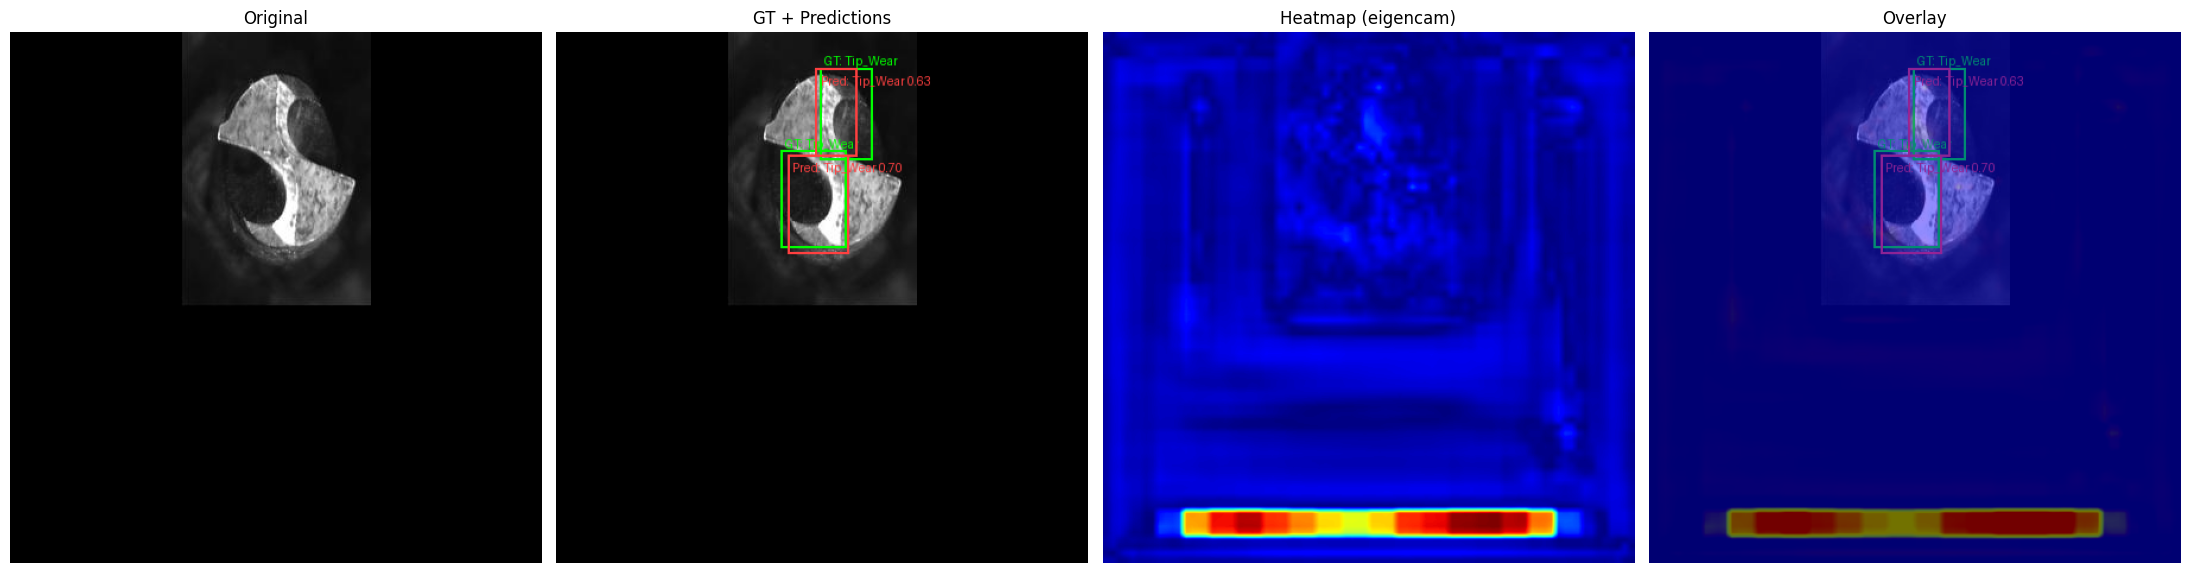

,class_id,class_name,confidence,xyxy
0,5,Tip_Wear,0.701425,"[195.2823944091797, 104.9786376953125, 246.535..."
1,5,Tip_Wear,0.627352,"[218.54893493652344, 31.734224319458008, 253.7..."


,class_id,class_name,xyxy
0,5,Tip_Wear,"[222.00012800000002, 31.000032000000004, 266.0..."
1,5,Tip_Wear,"[189.0, 100.99980800000002, 244.000064, 182.0]"


In [54]:
if sample_result is None:
    print("Khong co du doan nao vuot nguong conf tren anh mau.")
else:
    show_saliency_result(sample_result)

In [55]:
batch_results = run_saliency_batch(
    pipeline=pipeline,
    method=METHOD,
    imgsz=IMGSZ,
    conf=CONF,
    device=DEVICE,
    max_images=MAX_IMAGES,
)

summary_rows = []
for result in batch_results:
    summary_rows.append(
        {
            "image": result["image_path"].name,
            "method": result["method"],
            "target_layer": result["target_layer"],
            "pred_class": result["primary_prediction"]["class_name"],
            "confidence": result["primary_prediction"]["confidence"],
            "target_score": result["target_score"],
            "num_gt": len(result["ground_truth"]),
            "num_pred": len(result["predictions"]),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,image,method,target_layer,pred_class,confidence,target_score,num_gt,num_pred
0,side__S100_Image__2025-09-10__11-46-17_bright_...,eigencam,C3k2,Tip_Wear,0.701425,None,2,2
1,side__S101_Image__2025-09-10__12-16-33_dark_2_...,eigencam,C3k2,Broken,0.752553,None,2,2
2,side__S110_Image__2025-09-22__14-25-02_dark_1_...,eigencam,C3k2,Tip_Wear,0.803179,None,2,2
3,side__S111_Image__2025-09-22__14-52-58_bright_...,eigencam,C3k2,Tip_Wear,0.292253,None,1,1
4,side__S111_Image__2025-09-22__14-52-58_bright_...,eigencam,C3k2,Severe_Rust,0.785947,None,1,1
5,side__S111_Image__2025-09-22__14-52-58_bright_...,eigencam,C3k2,Tip_Wear,0.820959,None,2,2
6,side__S111_Image__2025-09-22__14-52-58_bright_...,eigencam,C3k2,Severe_Rust,0.766856,None,2,2


side__S100_Image__2025-09-10__11-46-17_bright_1_crop_9.jpg


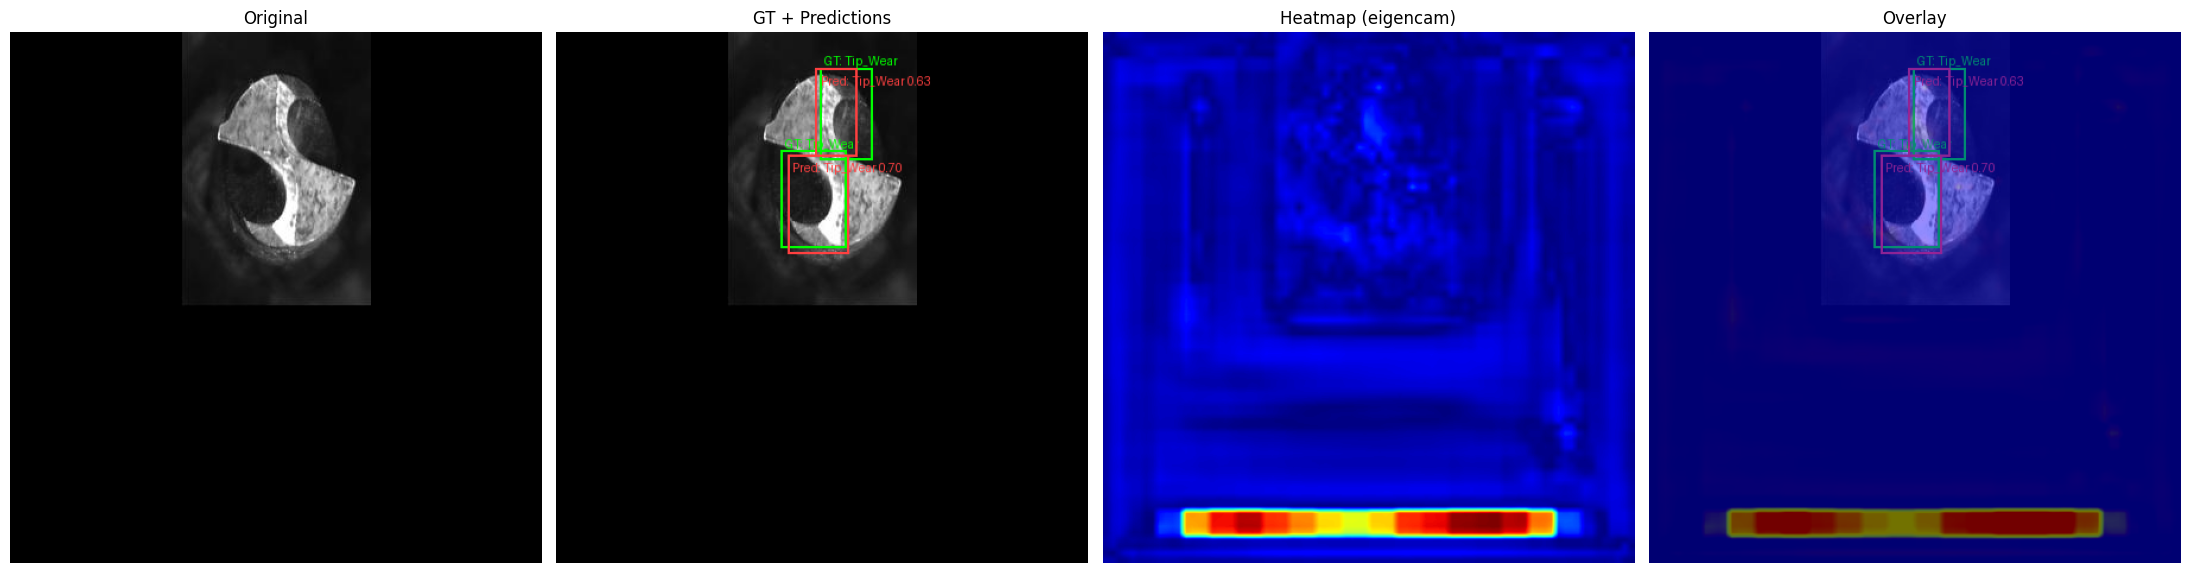

,class_id,class_name,confidence,xyxy
0,5,Tip_Wear,0.701425,"[195.2823944091797, 104.9786376953125, 246.535..."
1,5,Tip_Wear,0.627352,"[218.54893493652344, 31.734224319458008, 253.7..."


,class_id,class_name,xyxy
0,5,Tip_Wear,"[222.00012800000002, 31.000032000000004, 266.0..."
1,5,Tip_Wear,"[189.0, 100.99980800000002, 244.000064, 182.0]"


side__S101_Image__2025-09-10__12-16-33_dark_2_crop_4_jpg.jpg


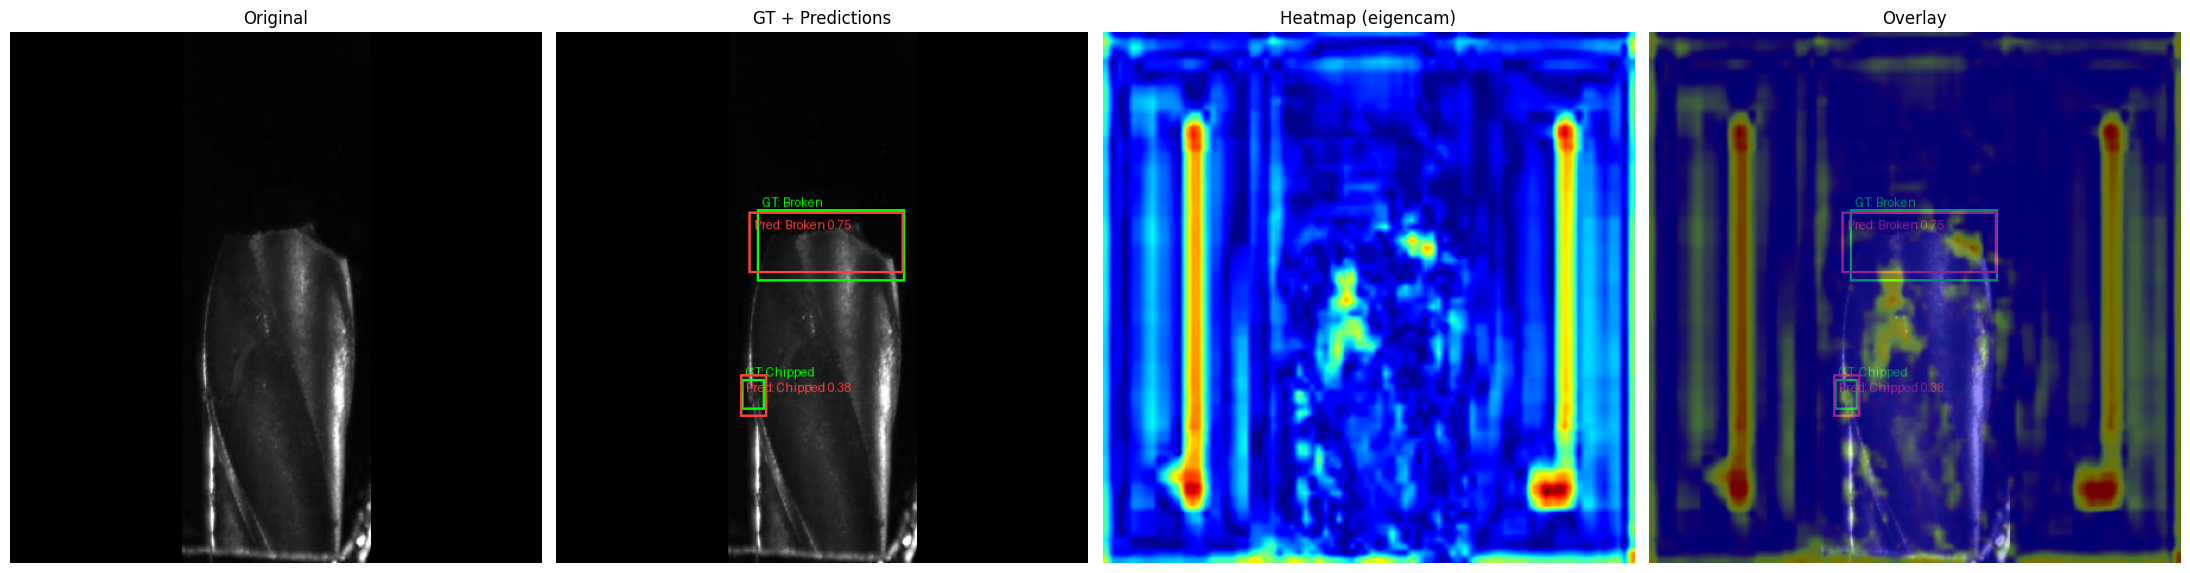

,class_id,class_name,confidence,xyxy
0,1,Broken,0.752553,"[162.7372589111328, 152.96853637695312, 292.92..."
1,2,Chipped,0.381060,"[155.5564727783203, 289.8331604003906, 177.954..."


,class_id,class_name,xyxy
0,1,Broken,"[169.99987199999998, 150.00003199999998, 293.0..."
1,2,Chipped,"[156.000096, 293.000064, 175.00022400000003, 3..."


side__S110_Image__2025-09-22__14-25-02_dark_1_crop_9.jpg


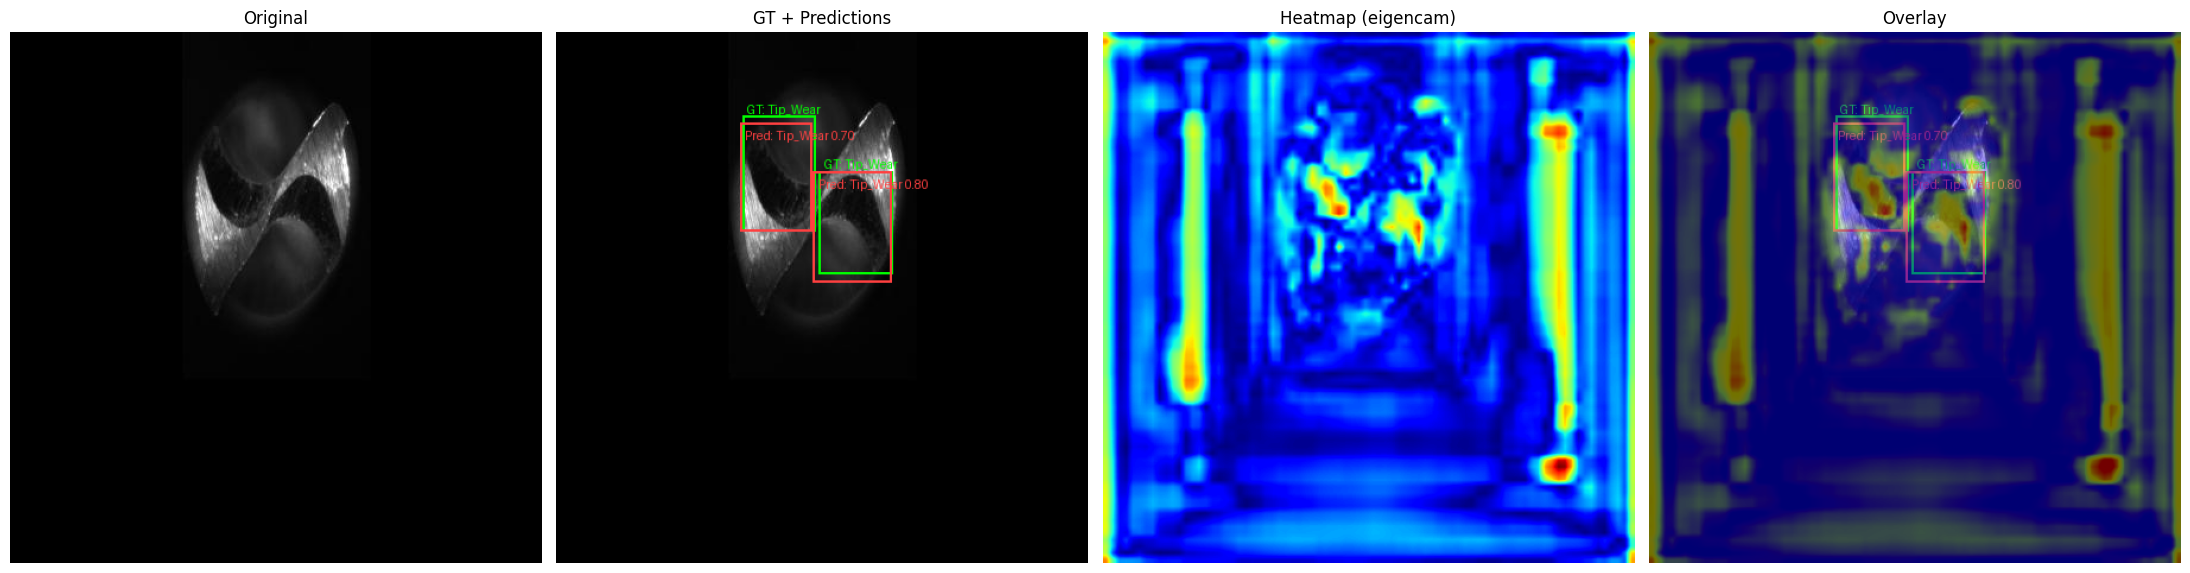

,class_id,class_name,confidence,xyxy
0,5,Tip_Wear,0.803179,"[216.98626708984375, 118.81826782226562, 282.6..."
1,5,Tip_Wear,0.701588,"[155.06317138671875, 77.65245056152344, 215.75..."


,class_id,class_name,xyxy
0,5,Tip_Wear,"[157.00003199999998, 71.99987200000001, 218.00..."
1,5,Tip_Wear,"[221.999904, 118.000064, 283.000032, 204.99987..."


In [56]:
# Hien thi nhanh 3 ket qua dau tien de xem saliency map thay doi the nao giua cac anh.
for result in batch_results[:3]:
    print(result["image_path"].name)
    show_saliency_result(result)

In [57]:
save_batch_results(
    results=batch_results,
    output_dir=OUTPUT_DIR,
    method=METHOD,
    split=SPLIT,
)

print(f"Saved notebook artifacts to: {OUTPUT_DIR / METHOD / SPLIT}")

Saved notebook artifacts to: /kaggle/working/saliency_maps/baseline/eigencam/val


In [58]:
# Ham nay dong hook cua CAM generator sau khi chay xong notebook de tranh giu tai nguyen.
pipeline["cam_generator"].close()

In [59]:
!rm -rf /kaggle/working/xai-driven-saliency-loss